# EDA: Intersection Size via Merge Cluster Diameter

This notebook explores whether the merge-cluster diameter from `01_merge_junctions` is a
viable proxy for physical intersection size.

**Goal:** before changing the photo-selection threshold in `04a_leg_selection`, verify
that cluster diameter meaningfully separates small street corners from large traffic squares.

Steps:
1. Re-derive merge clusters (same logic as notebook 01 — no outputs changed).
2. Compute cluster size (member count) and diameter (max pairwise distance between original points).
3. Summary stats + bar chart of cluster sizes.
4. Map a selection of the largest intersections with their diameter annotated.

In [41]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project\intersections"

# Input data — same files used in notebook 01
INTERSECTIONS_PATH = os.path.join(PROJECT_DIR, "data", "processed", "intersections.gpkg")
WEGVAKKEN_BST_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst.gpkg")
WEGVAKKEN_ROT_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam.gpkg")

CRS_RD = "EPSG:28992"  # RD New — all coordinates in metres

# Merge thresholds (must match notebook 01 exactly)
MERGE_THRESHOLD   = 25  # metres — FOW=2 signal
BAYONET_THRESHOLD =  6  # metres — bayonet/tight-proximity signal

## 1. Load data

In [42]:
# Load pre-merge intersections (5 846 rows) — these are the *original* NWB junctions
# before any merging has been applied.
intersections = gpd.read_file(INTERSECTIONS_PATH).set_index("JTE_ID")

# Load BST-filtered wegvakken — needed only to flag which junctions have FOW=2 connections
wegvakken = gpd.read_file(WEGVAKKEN_BST_PATH)

# Full gemeente wegvakken for visualisation background
wegvakken_viz = gpd.read_file(WEGVAKKEN_ROT_PATH)

print(f"Intersections (pre-merge): {len(intersections):,}")
print(f"Wegvakken (BST):           {len(wegvakken):,}")

Intersections (pre-merge): 5,846
Wegvakken (BST):           25,881


## 2. Re-derive merge clusters

Exact same logic as notebook 01, steps 2–4. This is read-only — no files are modified.

In [43]:
# --- Flag which junctions have at least TWO FOW=2 connections ---
# A true dual-carriageway junction sits on two parallel FOW=2 wegvakken
# (one per direction of travel), so count >= 2 is the correct signal.
# A junction with only 1 FOW=2 connection is typically at the fringe of a
# dual-carriageway section and should not trigger a merge on its own.
wvk_g = wegvakken[["JTE_ID_BEG", "JTE_ID_END", "FOW"]].copy()
wvk_g["FOW_int"] = pd.to_numeric(wvk_g["FOW"], errors="coerce")

# Build long-form table: one row per (junction_id, FOW_of_connected_segment)
jte_fow = pd.concat([
    wvk_g[["JTE_ID_BEG", "FOW_int"]].rename(columns={"JTE_ID_BEG": "JTE_ID"}),
    wvk_g[["JTE_ID_END", "FOW_int"]].rename(columns={"JTE_ID_END": "JTE_ID"}),
], ignore_index=True)

# Count how many FOW=2 segments connect to each junction
fow2_count   = jte_fow.groupby("JTE_ID")["FOW_int"].apply(lambda x: (x == 2).sum())
has_fow2     = fow2_count >= 2
fow2_flag    = has_fow2.reindex(intersections.index).fillna(False)
fow2_jte_set = set(fow2_flag[fow2_flag].index)

print(f"Junctions with >=2 FOW=2 connections: {fow2_flag.sum():,}")

# For comparison: how many had >=1 (the old threshold)
old_count = (jte_fow.groupby("JTE_ID")["FOW_int"]
             .apply(lambda x: (x == 2).any())
             .reindex(intersections.index).fillna(False).sum())
print(f"Junctions with >=1 FOW=2 connections: {old_count:,}  (old threshold, for reference)")

Junctions with >=2 FOW=2 connections: 2,105
Junctions with >=1 FOW=2 connections: 2,418  (old threshold, for reference)


In [44]:
# --- Find merge-candidate pairs via KD-tree ---
inter_ids    = np.array(intersections.index)
inter_coords = np.array([(g.x, g.y) for g in intersections.geometry])
tree         = cKDTree(inter_coords)

# Signal 1: pairs within MERGE_THRESHOLD where at least one side has FOW=2
pairs_30m  = tree.query_pairs(r=MERGE_THRESHOLD)
fow2_pairs = {
    (inter_ids[i], inter_ids[j])
    for i, j in pairs_30m
    if inter_ids[i] in fow2_jte_set or inter_ids[j] in fow2_jte_set
}

# Signal 2: bayonet pairs — any junction within BAYONET_THRESHOLD (no FOW filter needed)
pairs_bay     = tree.query_pairs(r=BAYONET_THRESHOLD)
bayonet_pairs = {(inter_ids[i], inter_ids[j]) for i, j in pairs_bay}

all_merge_pairs = list(fow2_pairs | bayonet_pairs)
print(f"Merge candidates: {len(all_merge_pairs):,} pairs")

Merge candidates: 1,311 pairs


In [45]:
# --- Connected components → one component = one logical intersection ---
n = len(intersections)
id_to_idx = {jte_id: idx for idx, jte_id in enumerate(inter_ids)}

if all_merge_pairs:
    rows = [id_to_idx[a] for a, b in all_merge_pairs] + [id_to_idx[b] for a, b in all_merge_pairs]
    cols = [id_to_idx[b] for a, b in all_merge_pairs] + [id_to_idx[a] for a, b in all_merge_pairs]
    adj  = csr_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)), shape=(n, n))
else:
    adj  = csr_matrix((n, n), dtype=np.int8)

n_components, labels = connected_components(adj, directed=False)
label_counts = pd.Series(labels).value_counts()
multi_labels = label_counts[label_counts > 1]  # clusters with >=2 members

print(f"Total connected components:         {n_components:,}")
print(f"  Multi-junction clusters (merged): {len(multi_labels):,}")
print(f"  Singleton clusters (unchanged):   {n_components - len(multi_labels):,}")

Total connected components:         4,890
  Multi-junction clusters (merged): 601
  Singleton clusters (unchanged):   4,289


## 3. Compute cluster size and diameter

In [46]:
# Build cluster_members dict and compute size + diameter for every cluster
# (including singletons, which have size=1 and diameter=0).
#
# Diameter = maximum straight-line distance between any two original member points.
# For a singleton this is 0. For a 2-junction cluster it's just the pair distance.
# For larger clusters we check all pairwise combinations (N is small, max ~6).

records = []  # one dict per logical (merged) intersection

for comp_label, size in label_counts.items():
    member_mask    = labels == comp_label
    member_jte_ids = inter_ids[member_mask]
    member_coords  = inter_coords[member_mask]   # (x, y) array, metres

    canonical_id = int(member_jte_ids.min())  # same convention as notebook 01

    # Diameter: max pairwise Euclidean distance between member points
    if size == 1:
        diameter_m = 0.0
    else:
        diameter_m = max(
            np.linalg.norm(member_coords[i] - member_coords[j])
            for i, j in combinations(range(size), 2)
        )

    records.append({
        "canonical_id":  canonical_id,
        "cluster_size":  int(size),
        "diameter_m":    diameter_m,
        "radius_m":      diameter_m / 2,
        "member_ids":    list(member_jte_ids),
        "member_coords": member_coords,
    })

cluster_df = pd.DataFrame(records).set_index("canonical_id")
print(f"Cluster records: {len(cluster_df):,}")
print(cluster_df[["cluster_size", "diameter_m"]].describe().round(1))

Cluster records: 4,890
       cluster_size  diameter_m
count        4890.0      4890.0
mean            1.2         2.1
std             0.6         6.6
min             1.0         0.0
25%             1.0         0.0
50%             1.0         0.0
75%             1.0         0.0
max             8.0        63.7


## 4. Summary statistics

In [47]:
n_total    = len(cluster_df)
n_single   = (cluster_df["cluster_size"] == 1).sum()
n_combined = (cluster_df["cluster_size"] > 1).sum()

print("=== Intersection size summary ===")
print(f"Total logical intersections:  {n_total:,}")
print(f"  Singletons (not merged):    {n_single:,}  ({n_single/n_total*100:.1f}%)")
print(f"  Combined (>=2 originals):   {n_combined:,}  ({n_combined/n_total*100:.1f}%)")
print()
print("Combined intersections — diameter distribution:")
print(cluster_df.loc[cluster_df["cluster_size"] > 1, "diameter_m"].describe().round(1))

=== Intersection size summary ===
Total logical intersections:  4,890
  Singletons (not merged):    4,289  (87.7%)
  Combined (>=2 originals):   601  (12.3%)

Combined intersections — diameter distribution:
count    601.0
mean      17.2
std        9.6
min        2.6
25%       10.9
50%       14.8
75%       22.3
max       63.7
Name: diameter_m, dtype: float64


## 5. Bar chart: how many original junctions per merged intersection

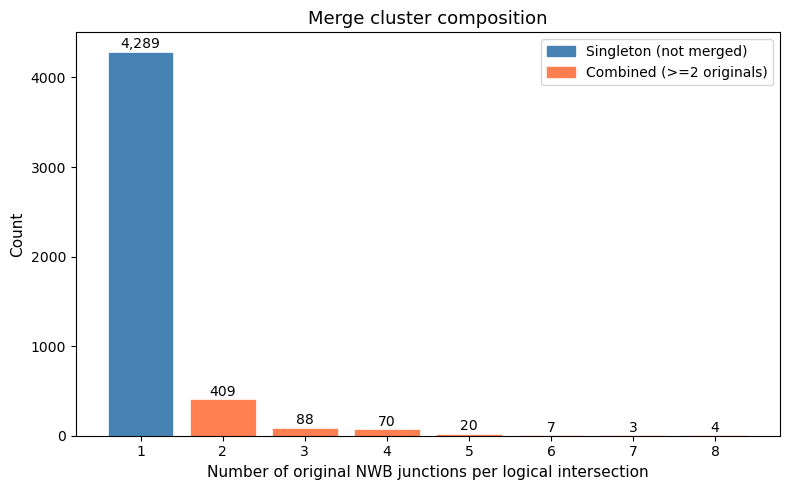

In [48]:
# Count how many logical intersections are made up of 1, 2, 3, ... original junctions
size_counts = cluster_df["cluster_size"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    size_counts.index,
    size_counts.values,
    color=["steelblue" if s == 1 else "coral" for s in size_counts.index],
    edgecolor="white",
    linewidth=0.5,
)

# Annotate each bar with the count
for bar, count in zip(bars, size_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count:,}",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_xlabel("Number of original NWB junctions per logical intersection", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Merge cluster composition", fontsize=13)
ax.set_xticks(size_counts.index)

# Legend
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Singleton (not merged)"),
    mpatches.Patch(color="coral",     label="Combined (>=2 originals)"),
], fontsize=10)

plt.tight_layout()
plt.show()

## 6. Visualise the largest intersections

Show the top 12 intersections by cluster diameter.
Each panel shows:
- Original member junction points (red dots)
- Merged centroid (black star)
- A circle with radius = cluster_radius_m
- The diameter value in the title

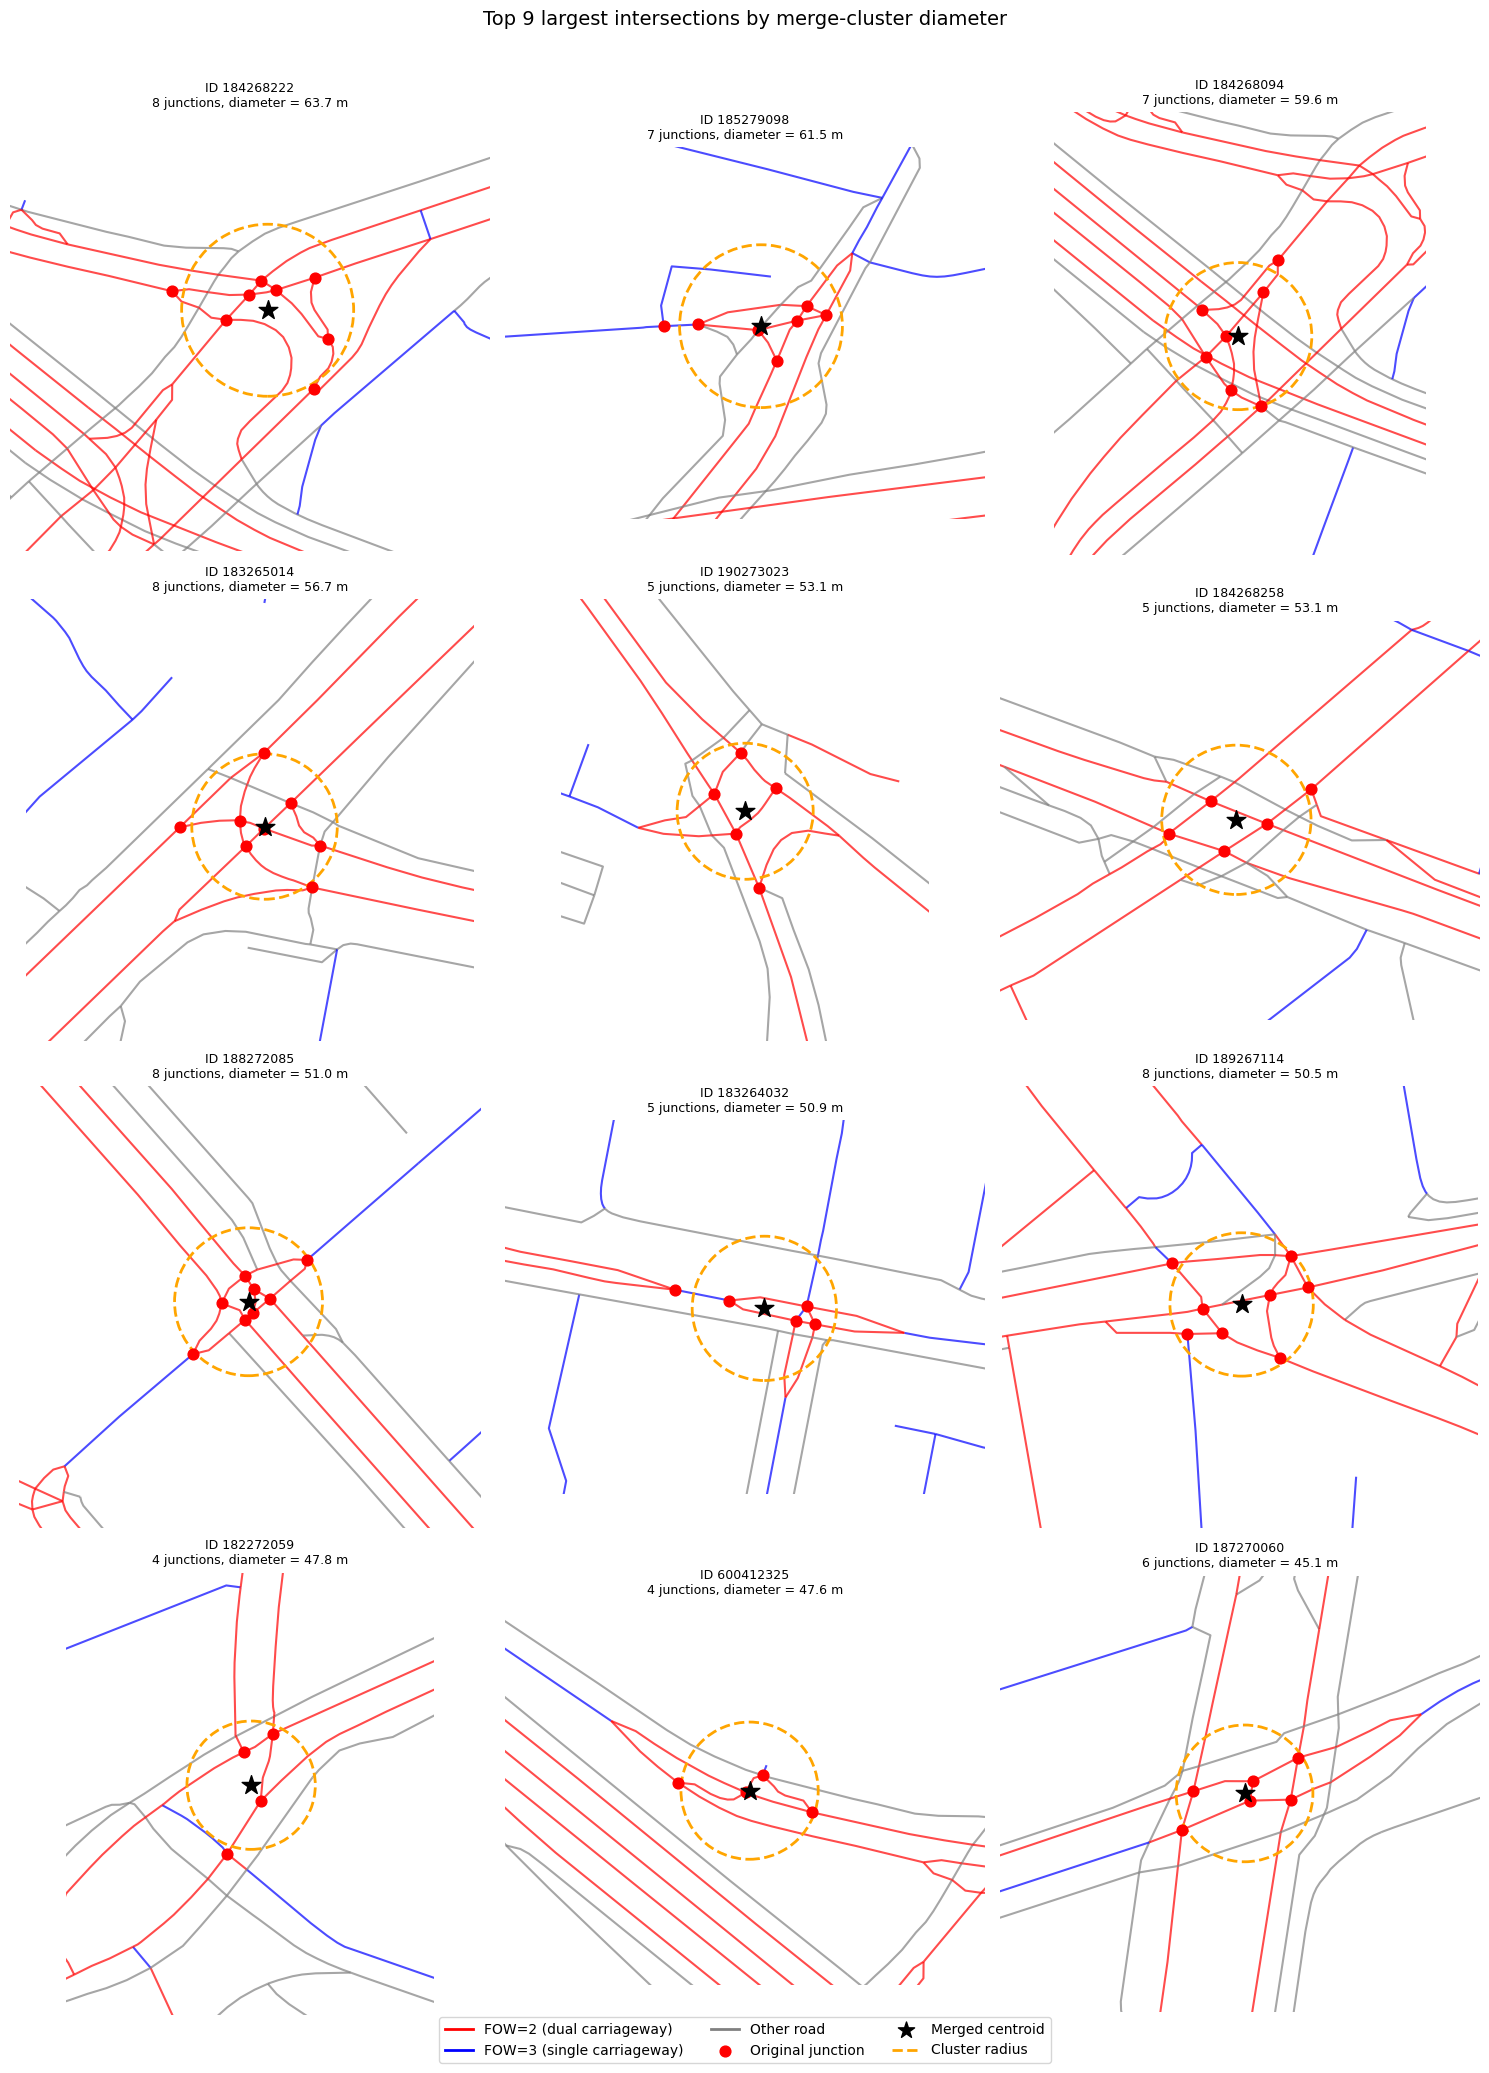

In [49]:
# Select top N combined intersections by diameter
N_SHOW   = 12
ZOOM_PAD = 60  # extra metres around the cluster bounding box

top = (
    cluster_df[cluster_df["cluster_size"] > 1]
    .sort_values("diameter_m", ascending=False)
    .head(N_SHOW)
)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for ax, (canonical_id, row) in zip(axes.flat, top.iterrows()):
    coords = row["member_coords"]  # array of (x, y) in metres

    # Bounding box for the zoom window
    x_min, y_min = coords.min(axis=0) - ZOOM_PAD
    x_max, y_max = coords.max(axis=0) + ZOOM_PAD

    # Background road network clipped to the zoom window
    bbox_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([x_min, x_max], [y_min, y_max]),
        crs=CRS_RD,
    )
    # Clip wegvakken to the bounding box for speed
    local_wvk = wegvakken_viz.cx[x_min:x_max, y_min:y_max]

    # Colour roads by FOW so dual carriageways stand out
    fow_colors = local_wvk["FOW"].map({"2": "red", "3": "blue"}).fillna("grey")
    local_wvk.plot(ax=ax, color=fow_colors, linewidth=1.5, alpha=0.7)

    # Original member junction points
    ax.scatter(coords[:, 0], coords[:, 1], color="red", s=60, zorder=5, label="Original junctions")

    # Merged centroid
    cx, cy = coords.mean(axis=0)
    ax.scatter(cx, cy, color="black", marker="*", s=200, zorder=6, label="Merged centroid")

    # Circle showing the cluster radius
    circle = plt.Circle(
        (cx, cy), row["radius_m"],
        fill=False, edgecolor="orange", linewidth=2, linestyle="--", zorder=4,
    )
    ax.add_patch(circle)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(
        f"ID {canonical_id}\n"
        f"{row['cluster_size']} junctions, diameter = {row['diameter_m']:.1f} m",
        fontsize=9,
    )
    ax.axis("off")

# Shared legend
handles = [
    plt.Line2D([0], [0], color="red",    linewidth=2, label="FOW=2 (dual carriageway)"),
    plt.Line2D([0], [0], color="blue",   linewidth=2, label="FOW=3 (single carriageway)"),
    plt.Line2D([0], [0], color="grey",   linewidth=2, label="Other road"),
    plt.scatter([], [], color="red",   s=60,  label="Original junction"),
    plt.scatter([], [], color="black", marker="*", s=150, label="Merged centroid"),
    plt.Line2D([0], [0], color="orange", linewidth=2, linestyle="--", label="Cluster radius"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Top 9 largest intersections by merge-cluster diameter", fontsize=14, y=1.01)

plt.tight_layout()
plt.show()

## 6b. Visualise the largest intersections by cluster size

Same layout as section 6, but sorted by **number of original NWB junctions** in the cluster (descending). Ties are broken by diameter. This highlights intersections where many junctions were merged, regardless of how spread out they are spatially.

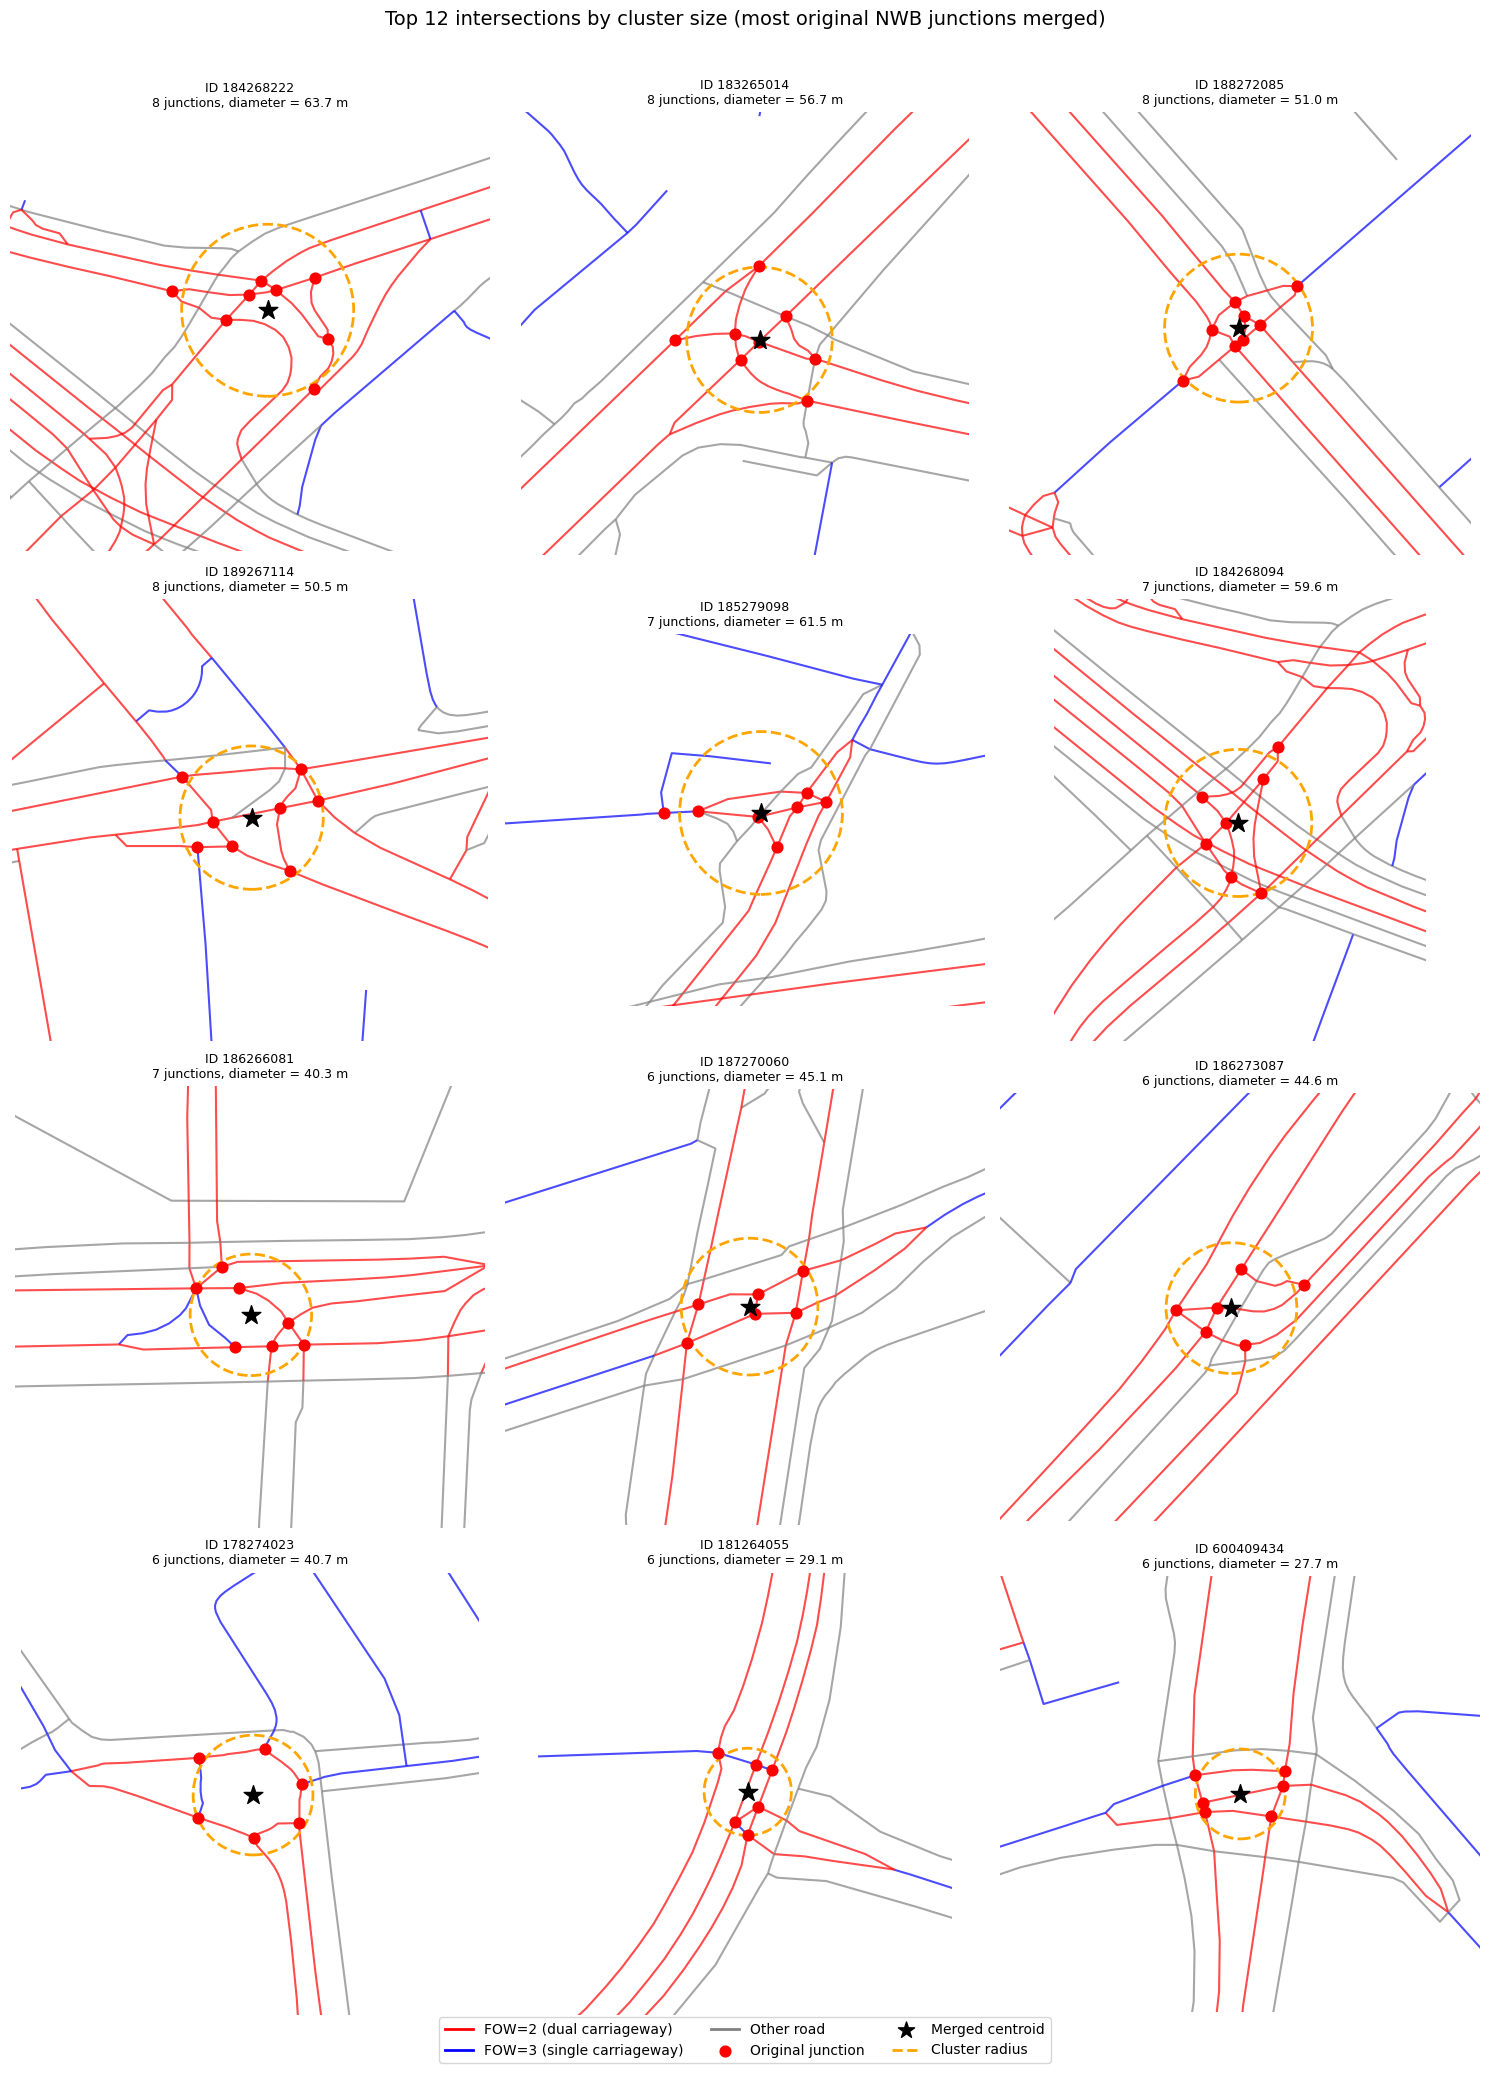

In [50]:
# Select top N combined intersections by cluster size (most original junctions merged).
# Ties in cluster_size are broken by diameter so the ordering is stable.
N_SHOW   = 12
ZOOM_PAD = 60  # extra metres around the cluster bounding box

top_by_size = (
    cluster_df[cluster_df["cluster_size"] > 1]
    .sort_values(["cluster_size", "diameter_m"], ascending=[False, False])
    .head(N_SHOW)
)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for ax, (canonical_id, row) in zip(axes.flat, top_by_size.iterrows()):
    coords = row["member_coords"]  # array of (x, y) in metres

    # Bounding box for the zoom window
    x_min, y_min = coords.min(axis=0) - ZOOM_PAD
    x_max, y_max = coords.max(axis=0) + ZOOM_PAD

    # Clip road network to the bounding box for speed
    local_wvk = wegvakken_viz.cx[x_min:x_max, y_min:y_max]

    # Colour roads by FOW so dual carriageways stand out
    fow_colors = local_wvk["FOW"].map({"2": "red", "3": "blue"}).fillna("grey")
    local_wvk.plot(ax=ax, color=fow_colors, linewidth=1.5, alpha=0.7)

    # Original member junction points
    ax.scatter(coords[:, 0], coords[:, 1], color="red", s=60, zorder=5, label="Original junctions")

    # Merged centroid
    cx, cy = coords.mean(axis=0)
    ax.scatter(cx, cy, color="black", marker="*", s=200, zorder=6, label="Merged centroid")

    # Circle showing the cluster radius
    circle = plt.Circle(
        (cx, cy), row["radius_m"],
        fill=False, edgecolor="orange", linewidth=2, linestyle="--", zorder=4,
    )
    ax.add_patch(circle)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(
        f"ID {canonical_id}\n"
        f"{row['cluster_size']} junctions, diameter = {row['diameter_m']:.1f} m",
        fontsize=9,
    )
    ax.axis("off")

# Shared legend
handles = [
    plt.Line2D([0], [0], color="red",    linewidth=2, label="FOW=2 (dual carriageway)"),
    plt.Line2D([0], [0], color="blue",   linewidth=2, label="FOW=3 (single carriageway)"),
    plt.Line2D([0], [0], color="grey",   linewidth=2, label="Other road"),
    plt.scatter([], [], color="red",   s=60,  label="Original junction"),
    plt.scatter([], [], color="black", marker="*", s=150, label="Merged centroid"),
    plt.Line2D([0], [0], color="orange", linewidth=2, linestyle="--", label="Cluster radius"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Top 12 intersections by cluster size (most original NWB junctions merged)", fontsize=14, y=1.01)

plt.tight_layout()
plt.show()


## 8. Missed junctions? — all intersections visible near the top-12 clusters

Same 9 viewports as the top-12 map, but now **all** pre-merge intersections in the
viewport are shown, not just the cluster members.

- **Red dots** — original junctions that *are* part of this merge cluster
- **Blue dots** — all other intersections in the viewport (singletons or members of a different cluster)

Use this to judge whether any nearby blue dot looks like it belongs to the same physical
intersection but was not pulled in by the merge logic.

C:\Users\Thijs\AppData\Local\Temp\ipykernel_13288\989797987.py:62: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  local_wvk[is_bidirectional].plot(ax=ax, color="steelblue", linewidth=2.0, alpha=0.85, zorder=2)
C:\Users\Thijs\AppData\Local\Temp\ipykernel_13288\989797987.py:62: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  local_wvk[is_bidirectional].plot(ax=ax, color="steelblue", linewidth=2.0, alpha=0.85, zorder=2)
C:\Users\Thijs\AppData\Local\Temp\ipykernel_13288\989797987.py:62: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  local_wvk[is_bidirectional].plot(ax=ax, color="steelblue", linewidth=2.0, alpha=0.85, zorder=2)
C:\Users\Thijs\AppData\Local\Temp\ipykernel_13288\989797987.py:62: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  local_wvk[is_bidirectional].plot(ax=ax, color="steelblue

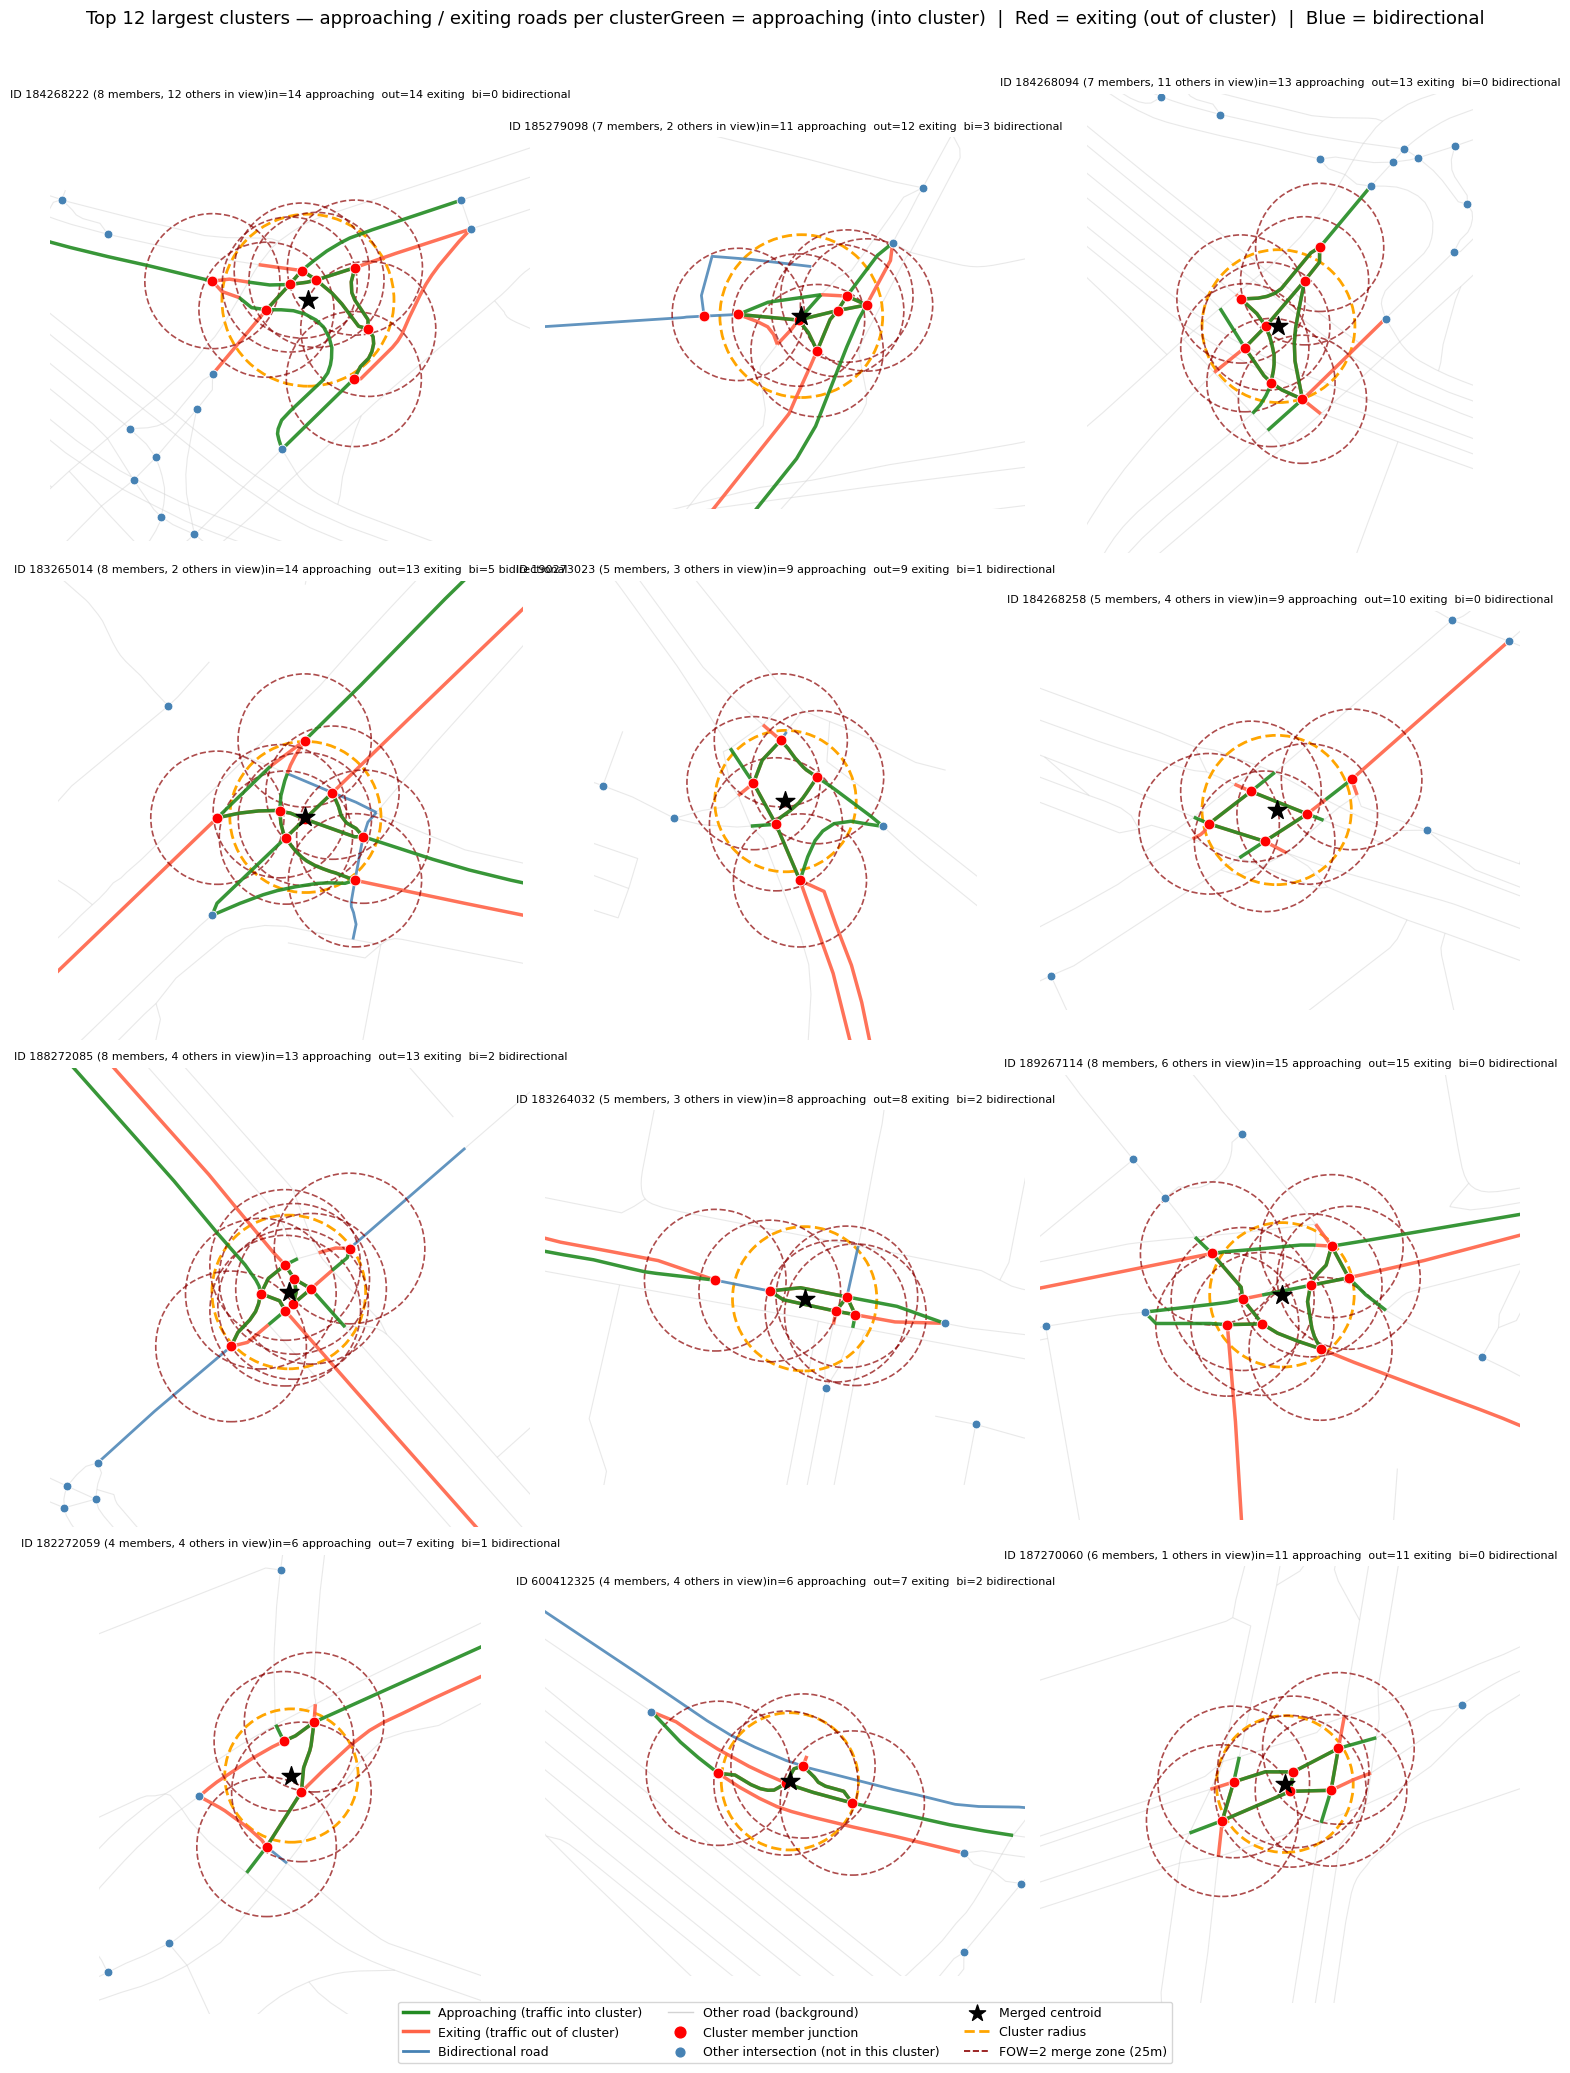

In [57]:
# Build a GeoDataFrame of all pre-merge intersections for spatial querying
all_inters_gdf = intersections.copy()  # indexed by JTE_ID, has geometry column

# Pre-compute direction column on the full visualisation dataset.
# We use wegvakken_viz (all gemeente roads) so we see all arms, not just BST roads.
# RIJRICHTNG values in NWB:
#   "H" = Heen (forward): traffic allowed BEG -> END only
#   "T" = Terug (backward): traffic allowed END -> BEG only
#   "B" = Beide (both directions)
wvk_dir = wegvakken_viz[["JTE_ID_BEG", "JTE_ID_END", "RIJRICHTNG", "geometry"]].copy()

# Build per-cluster member-ID sets for fast membership tests
cluster_member_sets = {
    cid: set(row["member_ids"])
    for cid, row in cluster_df.iterrows()
}

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for ax, (canonical_id, row) in zip(axes.flat, top.iterrows()):
    coords = row["member_coords"]
    member_ids_set = cluster_member_sets[canonical_id]

    # Viewport bounds (same zoom as the top-12 map)
    x_min, y_min = coords.min(axis=0) - ZOOM_PAD
    x_max, y_max = coords.max(axis=0) + ZOOM_PAD

    # Clip road network to viewport
    local_wvk = wvk_dir.cx[x_min:x_max, y_min:y_max].copy()

    # --- Classify each segment's direction relative to this cluster ---
    # "connected at BEG" means the segment starts at a cluster junction
    # "connected at END" means the segment ends at a cluster junction
    at_beg = local_wvk["JTE_ID_BEG"].isin(member_ids_set)
    at_end = local_wvk["JTE_ID_END"].isin(member_ids_set)
    connected = at_beg | at_end

    rij = local_wvk["RIJRICHTNG"]

    # Approaching: traffic flows TOWARD the cluster
    #   H (BEG->END) and segment arrives at cluster (at_end)
    #   T (END->BEG) and segment departs from cluster-end (at_beg)
    is_approaching = (
        ((rij == "H") & at_end) |
        ((rij == "T") & at_beg)
    )
    # Exiting: traffic flows AWAY FROM the cluster
    #   H (BEG->END) and segment leaves cluster (at_beg)
    #   T (END->BEG) and segment arrives at cluster (at_end, but traffic goes away)
    is_exiting = (
        ((rij == "H") & at_beg) |
        ((rij == "T") & at_end)
    )
    # Bidirectional: connected to cluster but both directions allowed
    is_bidirectional = connected & (rij == "B")

    # --- Draw roads in order: background first, then connected roads on top ---
    # Background (not connected to cluster): light grey for context
    local_wvk[~connected].plot(ax=ax, color="lightgray", linewidth=0.8, alpha=0.5, zorder=1)

    # Bidirectional roads: steel blue
    local_wvk[is_bidirectional].plot(ax=ax, color="steelblue", linewidth=2.0, alpha=0.85, zorder=2)

    # Exiting roads: tomato red
    local_wvk[is_exiting].plot(ax=ax, color="tomato", linewidth=2.5, alpha=0.9, zorder=3)

    # Approaching roads: forest green (drawn last so they appear on top)
    local_wvk[is_approaching].plot(ax=ax, color="forestgreen", linewidth=2.5, alpha=0.9, zorder=4)

    # --- All pre-merge intersections in the viewport ---
    local_all = all_inters_gdf.cx[x_min:x_max, y_min:y_max]
    is_member = local_all.index.isin(member_ids_set)
    others  = local_all[~is_member]
    members = local_all[is_member]

    # Others first (behind), cluster members on top
    if len(others) > 0:
        others.plot(ax=ax, color="steelblue", markersize=40, zorder=5,
                    edgecolors="white", linewidths=0.6)
    if len(members) > 0:
        members.plot(ax=ax, color="red", markersize=60, zorder=6,
                     edgecolors="white", linewidths=0.6)

    # --- FOW=2 merge zone: dashed circle around each FOW=2 member junction ---
    for mid, (mx, my) in zip(row["member_ids"], coords):
        if mid in fow2_jte_set:
            circle = plt.Circle(
                (mx, my), MERGE_THRESHOLD,
                fill=False, edgecolor="darkred", linewidth=1.2,
                linestyle="--", zorder=3, alpha=0.7,
            )
            ax.add_patch(circle)

    # Merged centroid
    cx, cy = coords.mean(axis=0)
    ax.scatter(cx, cy, color="black", marker="*", s=200, zorder=7)

    # Cluster radius circle
    circle = plt.Circle((cx, cy), row["radius_m"], fill=False,
                        edgecolor="orange", linewidth=2, linestyle="--")
    ax.add_patch(circle)

    # Count connected segments by type for the subtitle
    n_app  = is_approaching.sum()
    n_exit = is_exiting.sum()
    n_bi   = is_bidirectional.sum()

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(
        f"ID {canonical_id} ({row['cluster_size']} members, {len(others)} others in view)"
        f"in={n_app} approaching  out={n_exit} exiting  bi={n_bi} bidirectional",
        fontsize=8,
    )
    ax.axis("off")

# Shared legend
handles = [
    plt.Line2D([0], [0], color="forestgreen", linewidth=2.5, label="Approaching (traffic into cluster)"),
    plt.Line2D([0], [0], color="tomato",      linewidth=2.5, label="Exiting (traffic out of cluster)"),
    plt.Line2D([0], [0], color="steelblue",   linewidth=2.0, label="Bidirectional road"),
    plt.Line2D([0], [0], color="lightgray",   linewidth=1.0, label="Other road (background)"),
    plt.scatter([], [], color="red",       s=60,  label="Cluster member junction"),
    plt.scatter([], [], color="steelblue", s=40,  label="Other intersection (not in this cluster)"),
    plt.scatter([], [], color="black", marker="*", s=150, label="Merged centroid"),
    plt.Line2D([0], [0], color="orange",  linewidth=2, linestyle="--", label="Cluster radius"),
    plt.Line2D([0], [0], color="darkred", linewidth=1.2, linestyle="--",
               label=f"FOW=2 merge zone ({MERGE_THRESHOLD}m)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    "Top 12 largest clusters — approaching / exiting roads per cluster"
    "Green = approaching (into cluster)  |  Red = exiting (out of cluster)  |  Blue = bidirectional",
    fontsize=13, y=1.01,
)

plt.tight_layout()
plt.show()


## 7. Distribution of diameters among combined intersections

Histogram to see whether there is a natural break-point that could guide threshold selection.

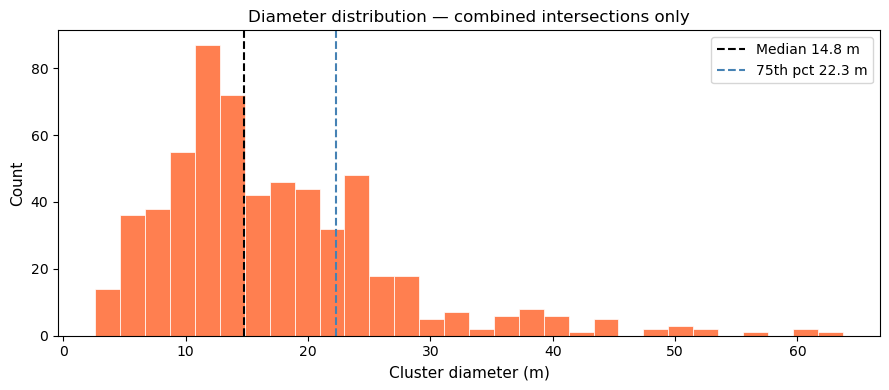

In [53]:
combined = cluster_df[cluster_df["cluster_size"] > 1]["diameter_m"]

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(combined, bins=30, color="coral", edgecolor="white", linewidth=0.5)
ax.axvline(combined.median(), color="black", linestyle="--", linewidth=1.5,
           label=f"Median {combined.median():.1f} m")
ax.axvline(combined.quantile(0.75), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"75th pct {combined.quantile(0.75):.1f} m")

ax.set_xlabel("Cluster diameter (m)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Diameter distribution — combined intersections only", fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 9. Experiment: direct FOW=2 connection rule

**Current rule (OR):** pair (A, B) is merged if within 25 m AND at least one of A, B has ≥2 FOW=2 connections.

**Problem:** a junction near a dual-carriageway junction can be pulled in even if the road connecting them is not a FOW=2 segment.

**Proposed rule (direct connection):** A and B must be *directly connected by a FOW=2 road segment* — i.e. there exists a `wegvak` with `FOW=2` whose endpoints are A and B.
This is the exact physical signal: the two parallel carriageway junctions at a divided-road crossing are linked by the short cross-connector, which is itself a FOW=2 segment.

The cells below re-derive clusters with this rule and compare the results.

In [54]:
# Build a set of junction-pairs that are directly connected by a FOW=2 segment.
# For each FOW=2 wegvak, record the (BEG, END) endpoint pair as a frozenset
# so lookup is direction-independent.

wvk_fow2 = wegvakken[pd.to_numeric(wegvakken['FOW'], errors='coerce') == 2]
fow2_edge_set = {
    frozenset([row['JTE_ID_BEG'], row['JTE_ID_END']])
    for _, row in wvk_fow2[['JTE_ID_BEG', 'JTE_ID_END']].iterrows()
}
print(f'FOW=2 segments: {len(wvk_fow2):,}  ->  {len(fow2_edge_set):,} unique endpoint pairs')

# Keep a proximity pair (A, B) only if a FOW=2 segment directly connects them.
# This is more precise than the OR rule (which only requires one side to have FOW=2
# connections, regardless of whether the connecting road itself is FOW=2).
fow2_pairs_direct = {
    (inter_ids[i], inter_ids[j])
    for i, j in pairs_30m
    if frozenset([inter_ids[i], inter_ids[j]]) in fow2_edge_set
}

all_merge_pairs_direct = list(fow2_pairs_direct | bayonet_pairs)

print('\n=== Pair counts: OR rule vs direct-FOW=2 rule ===')
print(f'FOW=2 pairs  (OR rule):     {len(fow2_pairs):>5,}')
print(f'FOW=2 pairs  (direct rule): {len(fow2_pairs_direct):>5,}  '
      f'(-{len(fow2_pairs) - len(fow2_pairs_direct):,} pairs dropped)')
print(f'Bayonet pairs (unchanged):  {len(bayonet_pairs):>5,}')
print(f'Total candidates (OR):      {len(list(fow2_pairs | bayonet_pairs)):>5,}')
print(f'Total candidates (direct):  {len(all_merge_pairs_direct):>5,}')

# Re-run connected components with the direct-connection pairs
if all_merge_pairs_direct:
    rows_d = ([id_to_idx[a] for a, b in all_merge_pairs_direct]
              + [id_to_idx[b] for a, b in all_merge_pairs_direct])
    cols_d = ([id_to_idx[b] for a, b in all_merge_pairs_direct]
              + [id_to_idx[a] for a, b in all_merge_pairs_direct])
    adj_direct = csr_matrix(
        (np.ones(len(rows_d), dtype=np.int8), (rows_d, cols_d)),
        shape=(n, n),
    )
else:
    adj_direct = csr_matrix((n, n), dtype=np.int8)

n_comp_direct, labels_direct = connected_components(adj_direct, directed=False)
lc_direct    = pd.Series(labels_direct).value_counts()
multi_direct = lc_direct[lc_direct > 1]

print(f'\n=== Cluster counts: OR rule vs direct-FOW=2 rule ===')
print(f'Multi-junction clusters (OR rule):     {len(multi_labels):,}')
print(f'Multi-junction clusters (direct rule): {len(multi_direct):,}  '
      f'(-{len(multi_labels) - len(multi_direct):,} clusters removed or split)')

# Build cluster_df_direct with same structure as cluster_df
records_direct = []
for comp_label, size in lc_direct.items():
    mask    = labels_direct == comp_label
    mids    = inter_ids[mask]
    mcoords = inter_coords[mask]
    cid     = int(mids.min())
    diam    = (0.0 if size == 1 else
               max(np.linalg.norm(mcoords[i] - mcoords[j])
                   for i, j in combinations(range(size), 2)))
    records_direct.append({
        'canonical_id':  cid,
        'cluster_size':  int(size),
        'diameter_m':    diam,
        'radius_m':      diam / 2,
        'member_ids':    list(mids),
        'member_coords': mcoords,
    })

cluster_df_direct = pd.DataFrame(records_direct).set_index('canonical_id')
print(f'\ncluster_df_direct rows: {len(cluster_df_direct):,}')


FOW=2 segments: 7,384  ->  7,349 unique endpoint pairs

=== Pair counts: OR rule vs direct-FOW=2 rule ===
FOW=2 pairs  (OR rule):     1,293
FOW=2 pairs  (direct rule):   594  (-699 pairs dropped)
Bayonet pairs (unchanged):     72
Total candidates (OR):      1,311
Total candidates (direct):    643

=== Cluster counts: OR rule vs direct-FOW=2 rule ===
Multi-junction clusters (OR rule):     601
Multi-junction clusters (direct rule): 281  (-320 clusters removed or split)

cluster_df_direct rows: 5,309


In [55]:
# Compare which clusters changed between OR rule and direct-FOW=2 rule.

or_multi     = cluster_df[cluster_df['cluster_size'] > 1]
direct_multi = cluster_df_direct[cluster_df_direct['cluster_size'] > 1]

lost_ids = set(or_multi.index) - set(direct_multi.index)
kept_ids = set(or_multi.index) & set(direct_multi.index)
shrank   = {cid for cid in kept_ids
            if cluster_df_direct.loc[cid, 'cluster_size'] < cluster_df.loc[cid, 'cluster_size']}

print('=== What changed (OR -> direct-FOW=2) ===')
print(f'Clusters lost or split:         {len(lost_ids):,}')
print(f'Clusters that shrank:           {len(shrank):,}')
print(f'Clusters unchanged:             {len(kept_ids) - len(shrank):,}')

# Side-by-side size distribution
size_or     = cluster_df['cluster_size'].value_counts().sort_index().rename('OR rule')
size_direct = cluster_df_direct['cluster_size'].value_counts().sort_index().rename('direct FOW=2')
print('\nCluster size distribution:')
print(pd.concat([size_or, size_direct], axis=1).fillna(0).astype(int).to_string())


=== What changed (OR -> direct-FOW=2) ===
Clusters lost or split:         350
Clusters that shrank:           42
Clusters unchanged:             209

Cluster size distribution:
              OR rule  direct FOW=2
cluster_size                       
1                4289          5028
2                 409           146
3                  88            55
4                  70            56
5                  20            13
6                   7             6
7                   3             4
8                   4             1


C:\Users\Thijs\AppData\Local\Temp\ipykernel_13288\1936113890.py:41: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  local_wvk[is_bidirectional].plot(ax=ax, color='steelblue',  linewidth=2.0, alpha=0.85, zorder=2)
C:\Users\Thijs\AppData\Local\Temp\ipykernel_13288\1936113890.py:41: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  local_wvk[is_bidirectional].plot(ax=ax, color='steelblue',  linewidth=2.0, alpha=0.85, zorder=2)
C:\Users\Thijs\AppData\Local\Temp\ipykernel_13288\1936113890.py:41: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  local_wvk[is_bidirectional].plot(ax=ax, color='steelblue',  linewidth=2.0, alpha=0.85, zorder=2)
C:\Users\Thijs\AppData\Local\Temp\ipykernel_13288\1936113890.py:41: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  local_wvk[is_bidirectional].plot(ax=ax, color='st

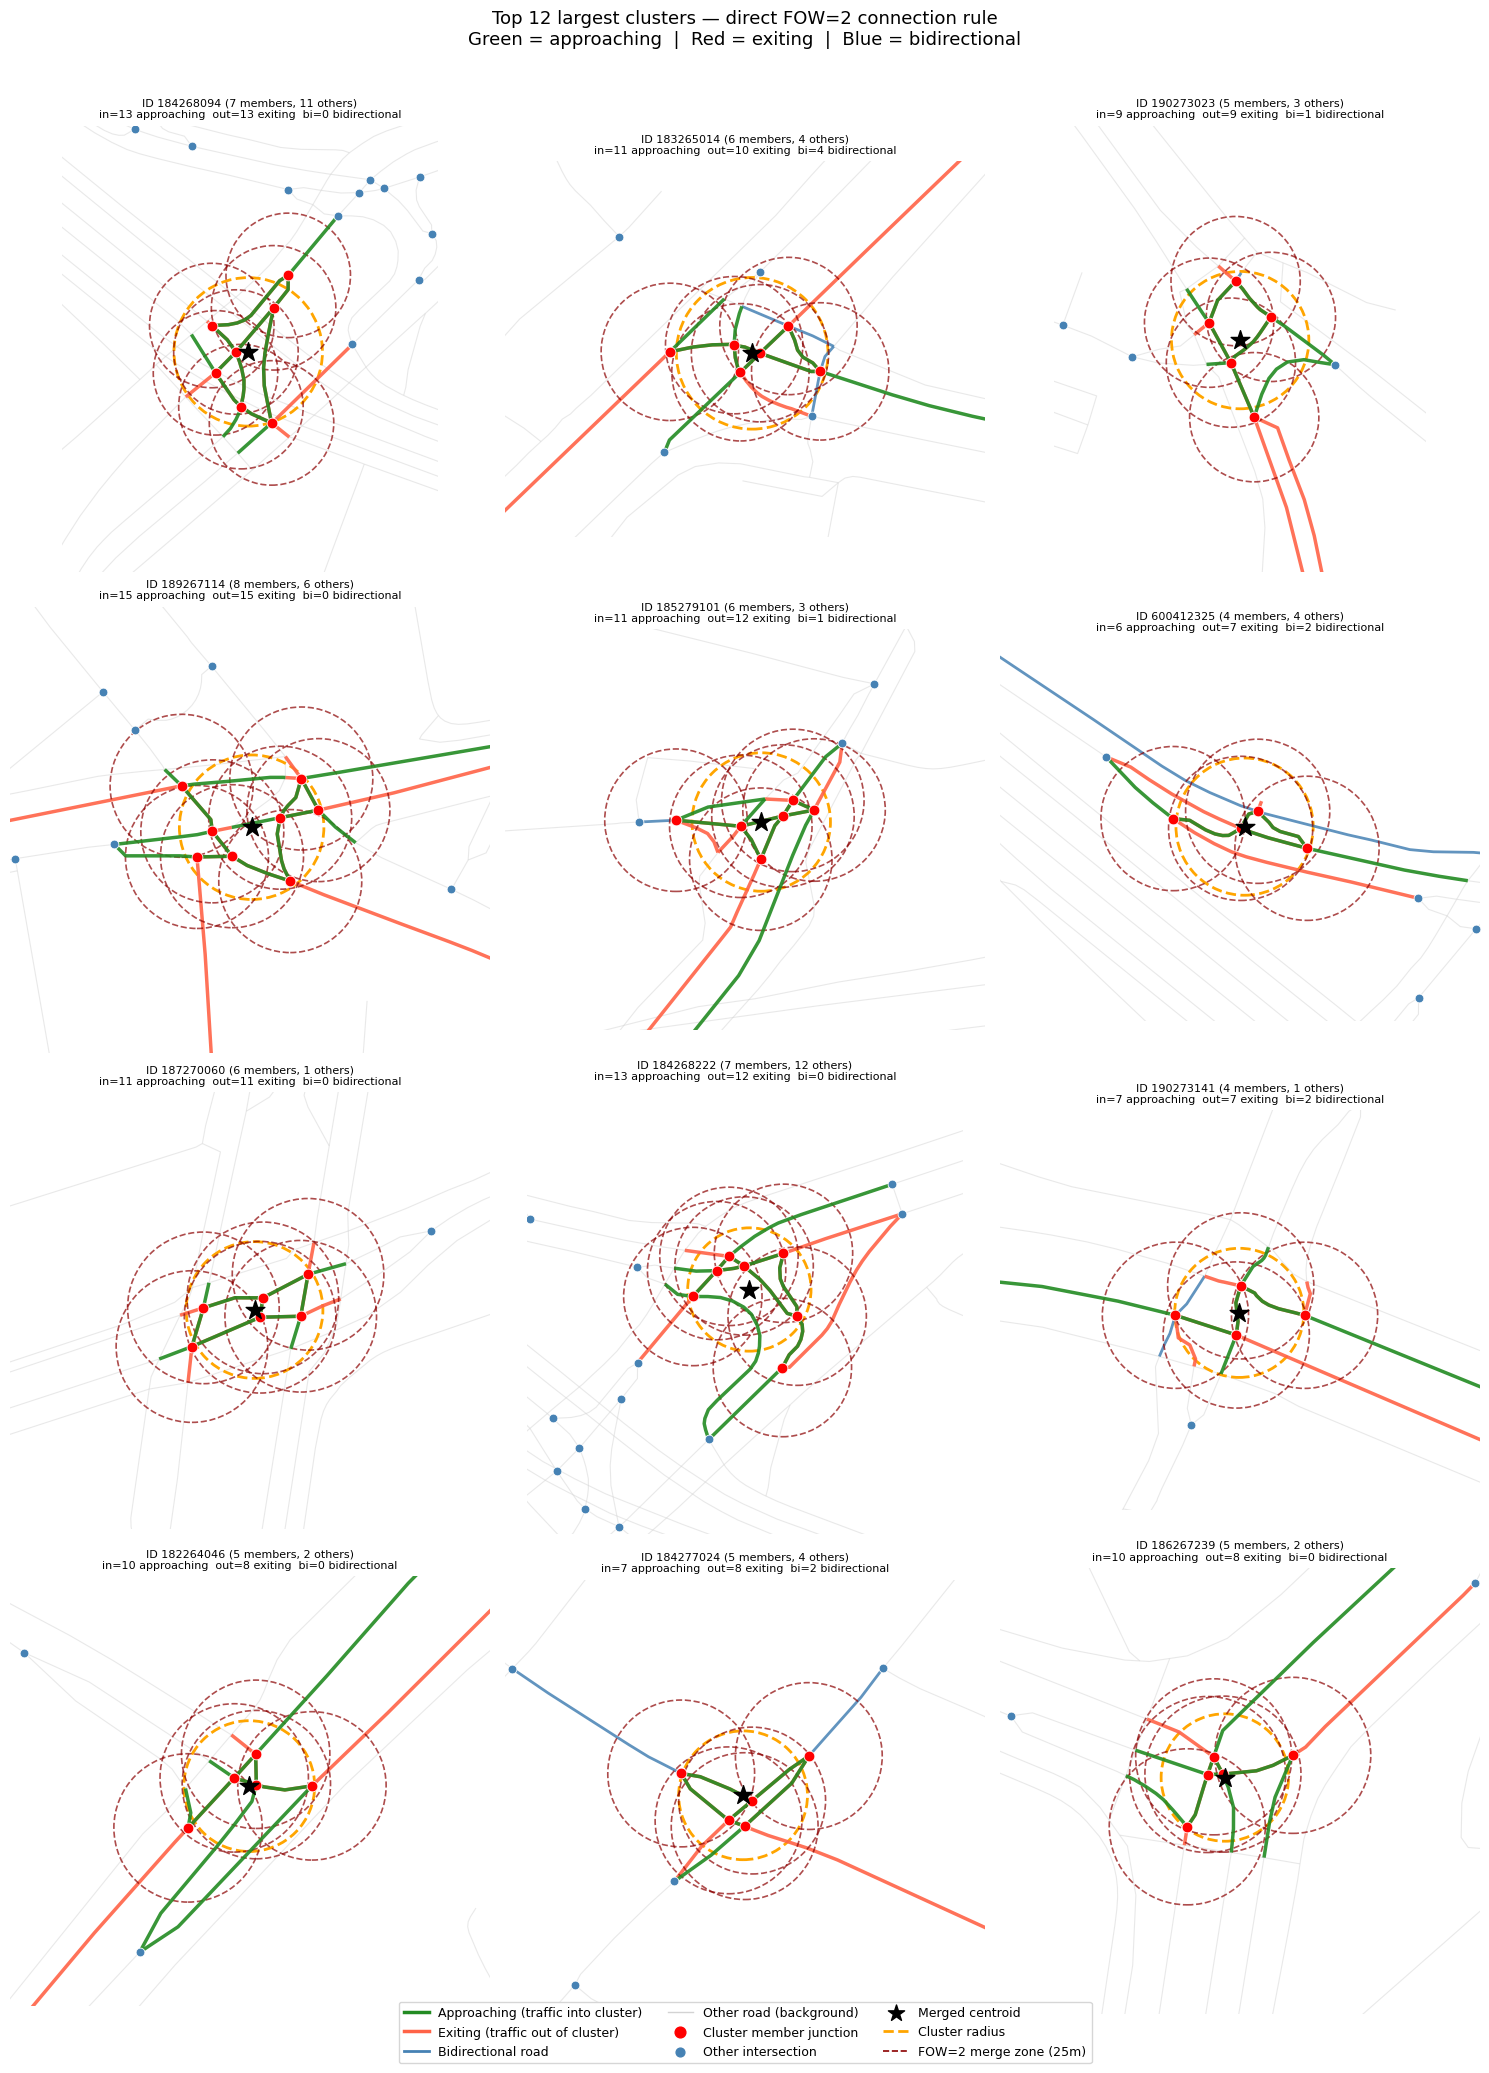

In [56]:
# Visualise the top 12 largest clusters under the direct-FOW=2 rule.
# Compare directly with the OR-rule plot above: the false-positive junction
# (connected by a bidirectional non-FOW=2 road) should no longer appear.

N_SHOW   = 12
ZOOM_PAD = 60

top_direct = (
    cluster_df_direct[cluster_df_direct['cluster_size'] > 1]
    .sort_values('diameter_m', ascending=False)
    .head(N_SHOW)
)

cluster_member_sets_direct = {
    cid: set(row['member_ids'])
    for cid, row in cluster_df_direct.iterrows()
}

fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for ax, (canonical_id, row) in zip(axes.flat, top_direct.iterrows()):
    coords         = row['member_coords']
    member_ids_set = cluster_member_sets_direct[canonical_id]

    x_min, y_min = coords.min(axis=0) - ZOOM_PAD
    x_max, y_max = coords.max(axis=0) + ZOOM_PAD

    local_wvk = wvk_dir.cx[x_min:x_max, y_min:y_max].copy()

    # Classify each segment's direction relative to this cluster
    at_beg    = local_wvk['JTE_ID_BEG'].isin(member_ids_set)
    at_end    = local_wvk['JTE_ID_END'].isin(member_ids_set)
    connected = at_beg | at_end
    rij       = local_wvk['RIJRICHTNG']

    is_approaching   = ((rij == 'H') & at_end) | ((rij == 'T') & at_beg)
    is_exiting       = ((rij == 'H') & at_beg) | ((rij == 'T') & at_end)
    is_bidirectional = connected & (rij == 'B')

    local_wvk[~connected].plot(ax=ax, color='lightgray',    linewidth=0.8, alpha=0.5,  zorder=1)
    local_wvk[is_bidirectional].plot(ax=ax, color='steelblue',  linewidth=2.0, alpha=0.85, zorder=2)
    local_wvk[is_exiting].plot(ax=ax,       color='tomato',      linewidth=2.5, alpha=0.9,  zorder=3)
    local_wvk[is_approaching].plot(ax=ax,   color='forestgreen', linewidth=2.5, alpha=0.9,  zorder=4)

    local_all = intersections.cx[x_min:x_max, y_min:y_max]
    is_member = local_all.index.isin(member_ids_set)
    others    = local_all[~is_member]
    members   = local_all[is_member]

    if len(others) > 0:
        others.plot(ax=ax, color='steelblue', markersize=40, zorder=5,
                    edgecolors='white', linewidths=0.6)
    if len(members) > 0:
        members.plot(ax=ax, color='red', markersize=60, zorder=6,
                     edgecolors='white', linewidths=0.6)

    # FOW=2 merge zone circles for cluster members that are on FOW=2 roads
    for mid, (mx, my) in zip(row['member_ids'], coords):
        if mid in fow2_jte_set:
            ax.add_patch(plt.Circle(
                (mx, my), MERGE_THRESHOLD,
                fill=False, edgecolor='darkred', linewidth=1.2,
                linestyle='--', zorder=3, alpha=0.7,
            ))

    cx, cy = coords.mean(axis=0)
    ax.scatter(cx, cy, color='black', marker='*', s=200, zorder=7)
    ax.add_patch(plt.Circle((cx, cy), row['radius_m'], fill=False,
                             edgecolor='orange', linewidth=2, linestyle='--'))

    n_app  = is_approaching.sum()
    n_exit = is_exiting.sum()
    n_bi   = is_bidirectional.sum()

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(
        f'ID {canonical_id} ({row["cluster_size"]} members, {len(others)} others)\n'
        f'in={n_app} approaching  out={n_exit} exiting  bi={n_bi} bidirectional',
        fontsize=8,
    )
    ax.axis('off')

handles = [
    plt.Line2D([0], [0], color='forestgreen', linewidth=2.5,
               label='Approaching (traffic into cluster)'),
    plt.Line2D([0], [0], color='tomato',      linewidth=2.5,
               label='Exiting (traffic out of cluster)'),
    plt.Line2D([0], [0], color='steelblue',   linewidth=2.0,
               label='Bidirectional road'),
    plt.Line2D([0], [0], color='lightgray',   linewidth=1.0,
               label='Other road (background)'),
    plt.scatter([], [], color='red',       s=60,  label='Cluster member junction'),
    plt.scatter([], [], color='steelblue', s=40,  label='Other intersection'),
    plt.scatter([], [], color='black', marker='*', s=150, label='Merged centroid'),
    plt.Line2D([0], [0], color='orange',  linewidth=2, linestyle='--',
               label='Cluster radius'),
    plt.Line2D([0], [0], color='darkred', linewidth=1.2, linestyle='--',
               label=f'FOW=2 merge zone ({MERGE_THRESHOLD}m)'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    'Top 12 largest clusters \u2014 direct FOW=2 connection rule\n'
    'Green = approaching  |  Red = exiting  |  Blue = bidirectional',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()
